# Mechanisms in BrainCell

This notebook now stays intentionally narrow.

`Ion` and `Channel` already have dedicated walkthroughs in `6.channel.ipynb` and `7.ion.ipynb`. Here we only keep the minimum density background needed to make point mechanisms concrete, then spend most of the notebook on **probes**.

At the declaration layer, the current multi-compartment mechanism surface still splits into two families:

- `Density`: installed with `cell.paint(region, ...)`
- `Point`: installed with `cell.place(locset, ...)`

`CableProperty` is closely related, but it is a passive cable declaration rather than a `Mechanism` subclass.

| Family | Declaration | Attach with | What matters most | Coverage here |
| --- | --- | --- | --- | --- |
| Passive cable declaration | `CableProperty` | `cell.paint(region, ...)` | Passive defaults such as `v_rest`, `cm`, `ra`, `temperature` | Short reminder |
| Density mech | `Ion` | `cell.paint(region, ...)` | Runtime ion containers and ion-side state | See `7.ion.ipynb` |
| Density mech | `Channel` | `cell.paint(region, ...)` | Distributed conductance mechanisms bound to ions | See `6.channel.ipynb` |
| Point mech | `CurrentClamp` / `SineClamp` / `FunctionClamp` | `cell.place(locset, ...)` | Current injection at point locations | Short refresher |
| Point mech | `StateProbe` / `MechanismProbe` / `CurrentProbe` | `cell.place(locset, ...)` | Read runtime state and current back out of the cell | Main focus |
| Point mech | `ProbeMechanism` / `Synapse` / `Junction` | `cell.place(locset, ...)` | Older or narrower workflows | Overview only |


In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("MPLBACKEND", "Agg")

import brainunit as u
import matplotlib.pyplot as plt

from braincell import Branch, Cell, Morphology
from braincell.filter import AllRegion, BranchSlice, RootLocation, Terminals, at
from braincell.mech import (
    CableProperty,
    Channel,
    CurrentClamp,
    CurrentProbe,
    FunctionClamp,
    Ion,
    MechanismProbe,
    SineClamp,
    StateProbe,
)


def build_demo_morphology() -> Morphology:
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[8.0, 8.0] * u.um,
        type="soma",
    )
    dend = Branch.from_lengths(
        lengths=[60.0] * u.um,
        radii=[2.0, 1.2] * u.um,
        type="basal_dendrite",
    )
    axon = Branch.from_lengths(
        lengths=[80.0] * u.um,
        radii=[1.0, 0.6] * u.um,
        type="axon",
    )
    morpho = Morphology.from_root(soma, name="soma")
    morpho.attach(parent="soma", child_branch=dend, child_name="dend", parent_x=1.0)
    morpho.attach(parent="soma", child_branch=axon, child_name="axon", parent_x=0.0)
    return morpho


## 1. Density declarations: only the minimum background

The density side has three layers:

1. `CableProperty` sets passive cable defaults.
2. `Ion` declares ion containers and any ion-side runtime state.
3. `Channel` installs distributed mechanisms that bind to those ions.

For the full density story, use the neighboring notebooks instead of this one:

- `4.cell.ipynb` for the paint/place workflow on `Cell`
- `6.channel.ipynb` for channel templates, gates, and generated ODEs
- `7.ion.ipynb` for ion templates, Nernst handling, and dynamic ion state

That is enough context for probes, because probes only become interesting after `Cell.init_state()` has materialized runtime state from these declarations.


### 1.1 `CableProperty`: paintable, central, but passive

`CableProperty` uses the same `paint(...)` entry point as density mechanisms, so it still belongs in the mental model even though it does not inherit from `Mechanism`.


In [2]:
morpho = build_demo_morphology()
print(morpho.topo())

cell_passive = Cell(morpho)
cell_passive.paint(
    AllRegion(),
    CableProperty(
        resting_potential=-65.0 * u.mV,
        membrane_capacitance=1.0 * (u.uF / u.cm**2),
        axial_resistivity=100.0 * (u.ohm * u.cm),
    ),
)

print()
print(cell_passive)
print("root CV resting potential:", cell_passive.cvs[0].v)


soma
├── dend
└── axon

Cell(root='soma', n_branches=3, n_paint_rules=1, n_place_rules=0, initialized=False)
root CV resting potential: -65. mV


## 2. Point mechanisms: stimuli versus observers

Point mechanisms live at one location in the point tree rather than across a branch interval.

For this notebook, the useful split is:

- **stimuli**: declarations that inject current at one point
- **observers**: declarations that read runtime values back out of the cell

Locsets decide **where** those declarations land. If you want the full locset vocabulary, see `2.filter.ipynb`.


### 2.1 Clamp declarations: a quick refresher

`CurrentClamp`, `SineClamp`, and `FunctionClamp` all feed the same runtime path: `cell.runtime.evaluate_point_clamps(t=...)`.

If several clamps are placed at the same point, their currents add. Since the rest of this notebook is probe-focused, we only keep one short runnable refresher here.


In [3]:
cell_clamp = Cell(build_demo_morphology())
cell_clamp.place(
    RootLocation(x=0.5),
    CurrentClamp(
        start=0.0 * u.ms,
        durations=(2.0 * u.ms, 2.0 * u.ms),
        amplitudes=(0.0 * u.nA, 0.3 * u.nA),
    ),
    SineClamp(
        amplitude=0.2 * u.nA,
        frequency=500.0 * u.Hz,
        offset=0.1 * u.nA,
        duration=4.0 * u.ms,
    ),
    FunctionClamp(
        fn=lambda local_t: 0.4 * u.nA if local_t < 1.0 * u.ms else 0.0 * u.nA,
        duration=3.0 * u.ms,
    ),
)
cell_clamp.init_state()

point_index = int(cell_clamp.layouts[0].point_index[0])
current_early = cell_clamp.runtime.evaluate_point_clamps(t=0.5 * u.ms)
current_late = cell_clamp.runtime.evaluate_point_clamps(t=2.5 * u.ms)

print("layout kinds:", [layout.kind for layout in cell_clamp.layouts])
print("active point index:", point_index)
print(f"combined clamp current at 0.5 ms: {float(current_early[point_index].to_decimal(u.nA)):.3f} nA")
print(f"combined clamp current at 2.5 ms: {float(current_late[point_index].to_decimal(u.nA)):.3f} nA")


layout kinds: ['CurrentClamp', 'SineClamp', 'FunctionClamp']
active point index: 1
combined clamp current at 0.5 ms: 0.700 nA
combined clamp current at 2.5 ms: 0.600 nA


### 2.2 Probes: the main observer surface

Probes are sparse point declarations. They do **not** allocate their own evolving state; they sample state or current that already exists elsewhere in the initialized runtime.

The three public probe types are:

- `StateProbe`: reads cell-owned state. In the current multi-compartment implementation, that means membrane voltage `v`.
- `MechanismProbe`: reads a runtime state field from a named mechanism or ion.
- `CurrentProbe`: reads the current of a named mechanism, or the total current of a named ion owner.

Once `cell.init_state()` has run, you can read probes in two ways:

- `cell.sample_probe(name)` reads one probe snapshot by name.
- `cell.sample_probes()` reads every probe snapshot as a `{name: value}` dictionary.

During time integration, `cell.run(...)` samples the same placed probes every timestep and returns them in `RunResult.traces`.


In [4]:
cell_probe = Cell(build_demo_morphology())
region = BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0)

cell_probe.paint(
    region,
    Channel("IL", g_max=0.03 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
    Ion(
        "CalciumDetailed",
        name="ca_dyn",
        d=0.5 * u.um,
        tau=10.0 * u.ms,
        C_rest=5.0e-5 * u.mM,
        Ci_initializer=2.4e-4 * u.mM,
    ),
)
cell_probe.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Channel("CaT_HM1992", ion_name="ca_dyn", g_max=2.0 * (u.mS / u.cm**2)),
)

cell_probe.place(
    at("soma", 0.5),
    StateProbe(),
    MechanismProbe(mechanism="Na_HH1952", field="p"),
    MechanismProbe(mechanism="ca_dyn", field="Ci"),
    CurrentProbe(ion="na", mechanism="Na_HH1952"),
    CurrentProbe(ion="na"),
    CurrentProbe(mechanism="IL"),
)
cell_probe.init_state()

samples = cell_probe.sample_probes()

print("probe keys:", sorted(samples))
print("single lookup via sample_probe:", float(cell_probe.sample_probe("soma(0.5)_Na_HH1952_p")))
print("soma(0.5)_v (mV):", float(samples["soma(0.5)_v"].to_decimal(u.mV)))
print("soma(0.5)_Na_HH1952_p:", float(samples["soma(0.5)_Na_HH1952_p"]))
print("soma(0.5)_ca_dyn_Ci (mM):", float(samples["soma(0.5)_ca_dyn_Ci"].to_decimal(u.mM)))
print(
    "soma(0.5)_Na_HH1952_current (mA / cm^2):",
    float(samples["soma(0.5)_Na_HH1952_current"].to_decimal(u.mA / u.cm**2)),
)
print(
    "soma(0.5)_na_current (mA / cm^2):",
    float(samples["soma(0.5)_na_current"].to_decimal(u.mA / u.cm**2)),
)
print(
    "soma(0.5)_IL_current (mA / cm^2):",
    float(samples["soma(0.5)_IL_current"].to_decimal(u.mA / u.cm**2)),
)


probe keys: ['soma(0.5)_IL_current', 'soma(0.5)_Na_HH1952_current', 'soma(0.5)_Na_HH1952_p', 'soma(0.5)_ca_dyn_Ci', 'soma(0.5)_na_current', 'soma(0.5)_v']
single lookup via sample_probe: 0.0
soma(0.5)_v (mV): -65.0
soma(0.5)_Na_HH1952_p: 0.0
soma(0.5)_ca_dyn_Ci (mM): 0.00024
soma(0.5)_Na_HH1952_current (mA / cm^2): 0.0
soma(0.5)_na_current (mA / cm^2): 0.0
soma(0.5)_IL_current (mA / cm^2): 0.00031838996801525354


### 2.3 What can a probe measure, exactly?

The practical rules are:

- `StateProbe(field="v")` reads cell-owned membrane voltage. In the current implementation, `v` is the only supported state field.
- `MechanismProbe(mechanism="Na_HH1952", field="p")` works well for channel gate variables and other runtime state stored as `brainstate.State`.
- `MechanismProbe` also works on **ion names**, not only on channel names. That is why `MechanismProbe(mechanism="ca_dyn", field="Ci")` can read the dynamic calcium concentration created by `Ion("CalciumDetailed", name="ca_dyn", ...)`.
- Static parameters are not valid probe fields. For example, `g_max` is a parameter, not runtime state.
- Derived properties are not valid probe fields either. For Nernst-style ions, `E` is computed from the current ion state; it is not stored as a standalone runtime `State`.
- `CurrentProbe(ion="na", mechanism="Na_HH1952")` reads one mechanism current.
- `CurrentProbe(mechanism="IL")` reads a mechanism current when the mechanism can evaluate `current(...)` without an explicit ion selector.
- `CurrentProbe(ion="na")` reads the **total** current of the named ion owner.

In the snapshot above, `soma(0.5)_Na_HH1952_current` and `soma(0.5)_na_current` happen to match because only one sodium channel is present. Once several sodium channels share the same ion owner, the ion-total probe becomes their sum.

Probe names matter because every runtime lookup is name-keyed:

- If you do not provide `name=...`, the lowerer auto-generates names such as `soma(0.5)_v` or `soma(0.5)_Na_HH1952_p`.
- If you do provide `name=...`, it must still be globally unique. Duplicate names will make `sample_probes()` and `run(...)` ambiguous.


In [5]:
morpho_multi = build_demo_morphology()
locset = RootLocation(x=0.5) | Terminals()

cell_multi = Cell(morpho_multi)
cell_multi.place(locset, StateProbe())
cell_multi.init_state()

print("locset display names:", morpho_multi.select(locset).display_names)
print("resolved probe keys:", sorted(cell_multi.sample_probes()))
print()
for layout in cell_multi.layouts:
    declaration = cell_multi.runtime.get_layout_mechanism(layout.id)
    print(layout.kind, layout.point_index.tolist(), declaration.name)


locset display names: ('soma(0.5)', 'dend(1)', 'axon(1)')
resolved probe keys: ['axon(1)_v', 'dend(1)_v', 'soma(0.5)_v']

state_probe:v:soma(0.5)_v [1] soma(0.5)_v
state_probe:v:dend(1)_v [3] dend(1)_v
state_probe:v:axon(1)_v [5] axon(1)_v


A locset that resolves to several points therefore produces several probes, one per selected point, each with its own resolved name. That is usually what you want for `sample_probes()` and for `RunResult.traces`, because each trace stays keyed by one concrete point location.


### 2.4 `CurrentProbe` on mixed-ion channels: owner versus modulators

Mixed-ion channels need one more piece of vocabulary.

`Kca3p1_MA2020` uses potassium as the **current owner**, while calcium acts as a **modulator** of the gating dynamics. In that case:

- `CurrentProbe(mechanism="Kca3p1_MA2020")` asks the mechanism itself for its current, using all ions that were bound to it at runtime.
- `CurrentProbe(ion="k_main")` asks the potassium owner for its **total** current, which may include several potassium channels.

To make that distinction visible, the example below adds a second potassium channel and briefly depolarizes the soma before comparing the two recorded currents.


In [6]:
cell_mixed = Cell(build_demo_morphology())
region = BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0)

cell_mixed.paint(
    region,
    Ion("PotassiumFixed", name="k_main", E=-88.0 * u.mV),
    Ion("CalciumFixed", name="ca_hva", Ci=2e-4 * u.mM),
    Ion("CalciumFixed", name="ca_lva", Ci=5e-4 * u.mM),
)
cell_mixed.paint(
    region,
    Channel("Kca3p1_MA2020", ion_names={"ca": "ca_hva"}),
    Channel("K_Kv_test", ion_name="k_main", g_max=1.0 * (u.mS / u.cm**2)),
)
cell_mixed.place(
    RootLocation(x=0.5),
    CurrentClamp.step(0.5 * u.nA, 10.0 * u.ms, delay=0.5 * u.ms),
)
cell_mixed.place(
    at("soma", 0.5),
    CurrentProbe(mechanism="Kca3p1_MA2020"),
    CurrentProbe(ion="k_main"),
)

result = cell_mixed.run(dt=0.05 * u.ms, duration=11.0 * u.ms)
layout = next(layout for layout in cell_mixed.layouts if layout.kind == "channel:Kca3p1_MA2020")
mech_trace = result.traces["soma(0.5)_Kca3p1_MA2020_current"].to_decimal(u.mA / u.cm**2)
total_trace = result.traces["soma(0.5)_k_main_current"].to_decimal(u.mA / u.cm**2)

print(sorted(result.traces))
print("bound ion keys:", cell_mixed.runtime.bound_ion_keys[layout.id])
print("current owner:", cell_mixed.runtime.current_owner_keys[layout.id])
print("last Kca mechanism current (mA / cm^2):", float(mech_trace[-1]))
print("last k_main total current (mA / cm^2):", float(total_trace[-1]))
print("difference at last timestep (mA / cm^2):", float(total_trace[-1] - mech_trace[-1]))


['soma(0.5)_Kca3p1_MA2020_current', 'soma(0.5)_k_main_current']
bound ion keys: ('k_main', 'ca_hva')
current owner: k_main
last Kca mechanism current (mA / cm^2): -0.022346971556544304
last k_main total current (mA / cm^2): -0.02325270138680935
difference at last timestep (mA / cm^2): -0.0009057298302650452


### 2.5 Probe traces during `cell.run(...)`

Snapshots are useful when you want the value **now**. For a time series, you do not place a different declaration: you place the same probes and then call `cell.run(...)`.

A few operational details matter:

- `cell.run(...)` auto-calls `init_state()` if the cell is still in DECLARING.
- `cell.run(...)` requires at least one placed probe, because its trace output is probe-driven.
- The return value is `RunResult(time=..., traces=...)`, where `traces` is a dictionary keyed by probe name.

Below we drive the soma with a step current and record three traces from the same point: membrane voltage, one sodium gate variable, and the sodium mechanism current.


trace keys: ['soma(0.5)_Na_HH1952_current', 'soma(0.5)_Na_HH1952_p', 'soma(0.5)_v']
n timesteps: 240
current time after run (ms): 12.0


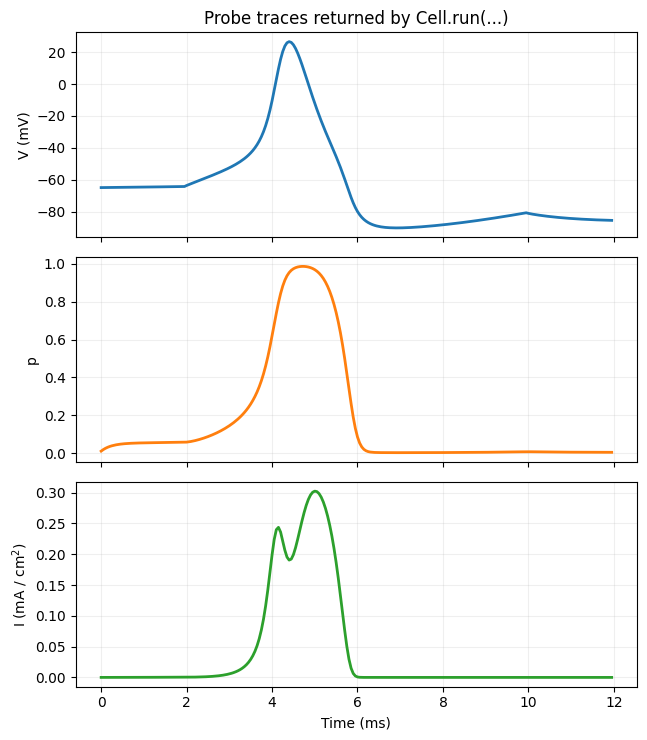

In [7]:
sim_cell = Cell(build_demo_morphology())
sim_region = BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0)

sim_cell.paint(
    sim_region,
    Channel("IL", g_max=0.03 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
    Channel("K_HH1952", g_max=36.0 * (u.mS / u.cm**2)),
)

sim_cell.place(
    RootLocation(x=0.5),
    CurrentClamp.step(0.2 * u.nA, 8.0 * u.ms, delay=2.0 * u.ms),
)
sim_cell.place(
    at("soma", 0.5),
    StateProbe(),
    MechanismProbe(mechanism="Na_HH1952", field="p"),
    CurrentProbe(ion="na", mechanism="Na_HH1952"),
)

result = sim_cell.run(dt=0.05 * u.ms, duration=12.0 * u.ms)

print("trace keys:", sorted(result.traces))
print("n timesteps:", int(result.time.shape[0]))
print("current time after run (ms):", float(sim_cell.current_time.to_decimal(u.ms)))

fig, axes = plt.subplots(3, 1, figsize=(6.5, 7.5), sharex=True)

times_ms = result.time.to_decimal(u.ms)
axes[0].plot(times_ms, result.traces["soma(0.5)_v"].to_decimal(u.mV), color="#1f77b4", linewidth=2.0)
axes[0].set_ylabel("V (mV)")
axes[0].set_title("Probe traces returned by Cell.run(...)")
axes[0].grid(True, alpha=0.2)

axes[1].plot(times_ms, result.traces["soma(0.5)_Na_HH1952_p"], color="#ff7f0e", linewidth=2.0)
axes[1].set_ylabel("p")
axes[1].grid(True, alpha=0.2)

axes[2].plot(
    times_ms,
    result.traces["soma(0.5)_Na_HH1952_current"].to_decimal(u.mA / u.cm**2),
    color="#2ca02c",
    linewidth=2.0,
)
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("I (mA / cm$^2$)")
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


### 2.6 Other point declarations

Three public point declarations are worth knowing even though this notebook does not build their full workflows.

- `ProbeMechanism(variable="v", target="soma")` is the older variable-by-name recorder. For new multi-compartment code, prefer `StateProbe`, `MechanismProbe`, and `CurrentProbe` when you want explicit selectors.
- `Synapse(synapse_type="AMPA", ...)` is the registry-keyed synapse declaration surface.
- `Junction(...)` is the current placeholder for gap-junction-style point declarations.


## Summary

The mechanism surface in the current multi-compartment stack is still small, but the probe story is already quite usable:

- `CableProperty`, `Ion`, and `Channel` create the runtime objects that probes later observe.
- `StateProbe` is the voltage probe: today it supports only `v`.
- `MechanismProbe` reads named runtime state on a channel or ion, as long as the field is a real runtime `State`.
- `CurrentProbe` can read one mechanism current or one ion owner's total current.
- `cell.sample_probe(...)` and `cell.sample_probes()` give immediate snapshots after `init_state()`.
- `cell.run(...)` records the same placed probes over time and returns them by probe name in `RunResult.traces`.

For more declaration detail, continue with `6.channel.ipynb` and `7.ion.ipynb`. For more locset detail, continue with `2.filter.ipynb`.
